In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tfgans import utils
from tfgans.pix2pix import models 

2026-09-17 12:03:26.848922: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-17 12:03:26.848951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-17 12:03:26.849614: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-17 12:03:26.853659: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-17 12:03:27.517429: W tensorflow/compiler/tf2

In [2]:
src_dir = "/home/sagar/projects/GHOST/data/processed/lung/ct/"
tar_dir = "/home/sagar/projects/GHOST/data/processed/lung/histo/"

In [3]:
src_data = utils.load_images_in_shape(src_dir, color_mode="grayscale")
tar_data = utils.load_images_in_shape(tar_dir, color_mode="rgb")

Found 896 files in the directory


  0%|          | 0/896 [00:00<?, ?it/s]

100%|██████████| 896/896 [00:00<00:00, 2124.35it/s]


Loaded (896, 256, 256, 1) images
Found 896 files in the directory


100%|██████████| 896/896 [00:00<00:00, 1363.48it/s]


Loaded (896, 256, 256, 3) images


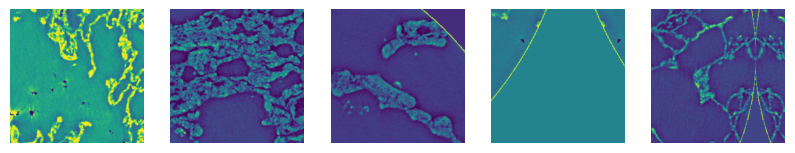

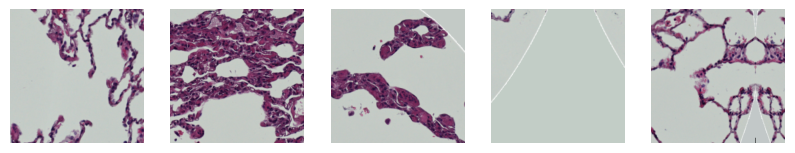

In [4]:
idxA = np.random.randint(0, len(src_data), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(idxA):
    plt.subplot(1, 5, 1 + i)
    plt.axis('off')
    plt.imshow(src_data[idx].astype('uint8'))
plt.show()
plt.figure(figsize=(10,5))
for i, idx in enumerate(idxA):
    plt.subplot(1, 5, 1 + i)
    plt.axis('off')
    plt.imshow(tar_data[idx].astype('uint8'))
plt.show()

In [5]:
src = utils.scale_data(src_data)
tar = utils.scale_data(tar_data)

In [ ]:
# define image shape
src_shape = src.shape[1:]
tar_shape = tar.shape[1:]
# define the models
disc = models.build_discriminator(src_shape, tar_shape)
gene = models.build_generator(src_shape, output_channel=tar_shape[-1])
# define the composite model
p2p_model = models.build_pix2pix(gene, disc)

# training output directory
output_folder = "../training_output/"
name = "pix2pix"
output_dir = os.path.join(output_folder, name)

# train the model
models.train_pix2pix(gene, disc, p2p_model, src, tar, epochs=10, summary_interval=2, name=output_dir)